# TP 1 — scikit-image : solution commentée

Solution complète du [TP 1](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, filters, measure, morphology, util
from skimage.restoration import denoise_bilateral
from skimage.util import img_as_float

rng = np.random.default_rng(0)
img = data.camera()

## Exercice 1 — Bruit et débruitage

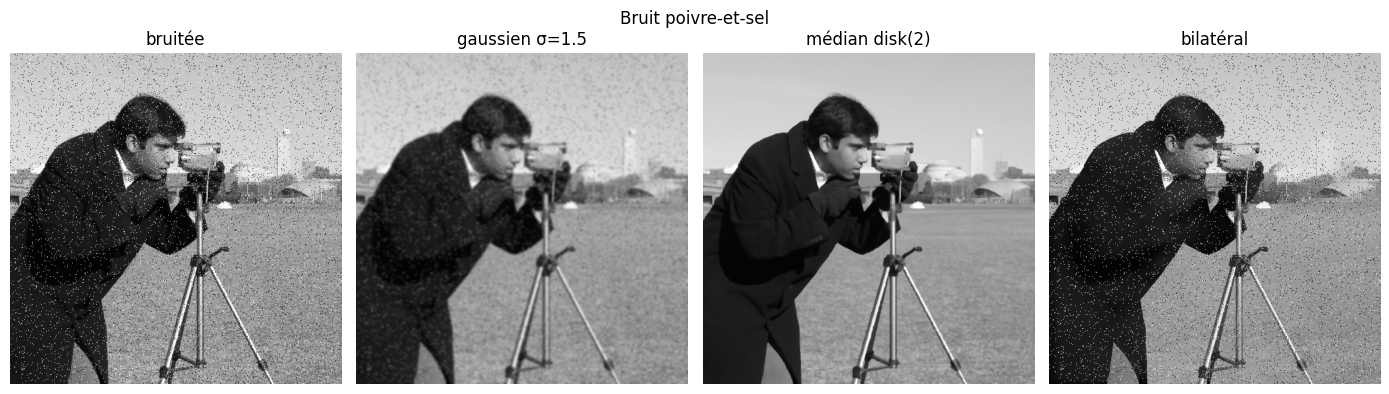

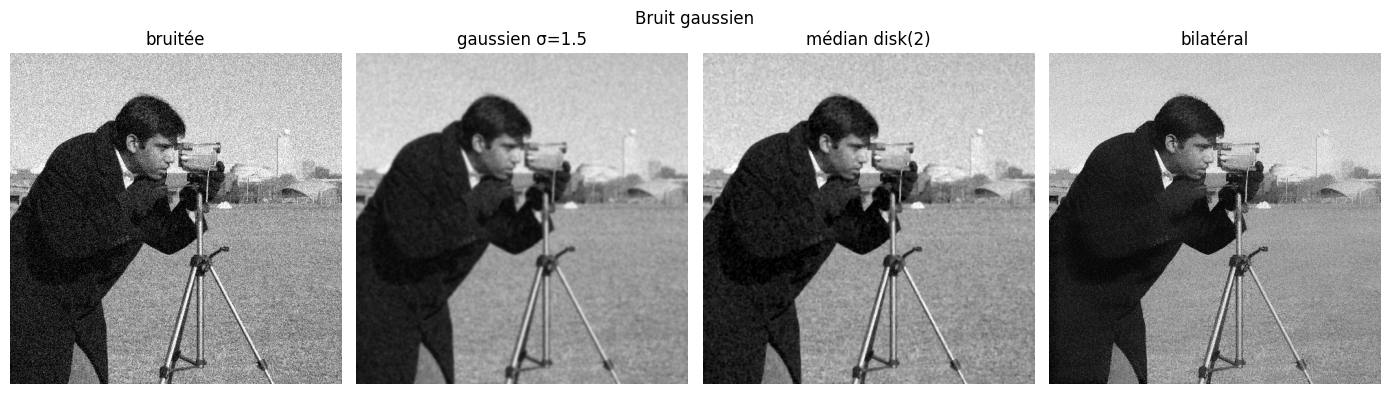

In [2]:
img_f = img_as_float(img)
img_sp = util.random_noise(img_f, mode="s&p", amount=0.05, rng=rng)
img_g = util.random_noise(img_f, mode="gaussian", var=0.01, rng=rng)


def filter_all(im):
    g = filters.gaussian(im, sigma=1.5)
    m = filters.median(im, morphology.disk(2))
    b = denoise_bilateral(im, sigma_color=0.1, sigma_spatial=5)
    return g, m, b


titles = ["bruitée", "gaussien σ=1.5", "médian disk(2)", "bilatéral"]

for name, noisy in [("poivre-et-sel", img_sp), ("gaussien", img_g)]:
    g, m, b = filter_all(noisy)
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, im, t in zip(axes, [noisy, g, m, b], titles):
        ax.imshow(im, cmap="gray", vmin=0, vmax=1)
        ax.set_title(t)
        ax.axis("off")
    fig.suptitle(f"Bruit {name}")
    plt.tight_layout()

**Observation** : le filtre **médian** écrase complètement le bruit poivre-et-sel (par construction, une médiane est insensible à quelques pixels aberrants). Le **gaussien** floute uniformément, ce qui n'enlève pas les impulsions mais réduit bien un bruit gaussien. Le **bilatéral** est un bon compromis, surtout sur bruit gaussien, car il préserve les bords.

## Exercice 2 — Morphologie sur un masque binaire

/var/folders/8m/l_690lqs2v51h4cv_vz7lllr0000gn/T/ipykernel_56499/3741580958.py:5: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask_open = morphology.binary_opening(mask, morphology.disk(1))
/var/folders/8m/l_690lqs2v51h4cv_vz7lllr0000gn/T/ipykernel_56499/3741580958.py:6: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask_close = morphology.binary_closing(mask_open, morphology.disk(3))


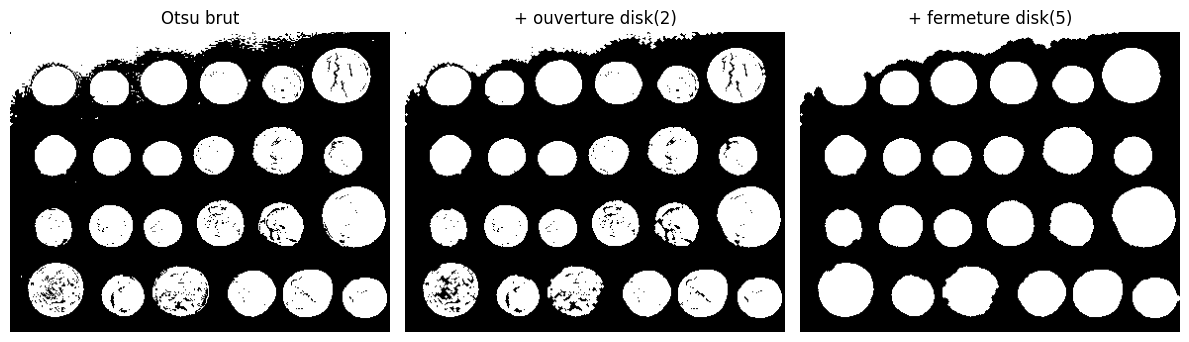

In [15]:
coins = data.coins()
t = filters.threshold_otsu(coins)
mask = coins > t

mask_open = morphology.binary_opening(mask, morphology.disk(1))
mask_close = morphology.binary_closing(mask_open, morphology.disk(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, m, title in zip(
    axes,
    [mask, mask_open, mask_close],
    ["Otsu brut", "+ ouverture disk(2)", "+ fermeture disk(5)"],
):
    ax.imshow(m, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

## Exercice 3 — Compter et caractériser

21 pièces détectées
aire : moyenne=2172, médiane=1471, std=2245


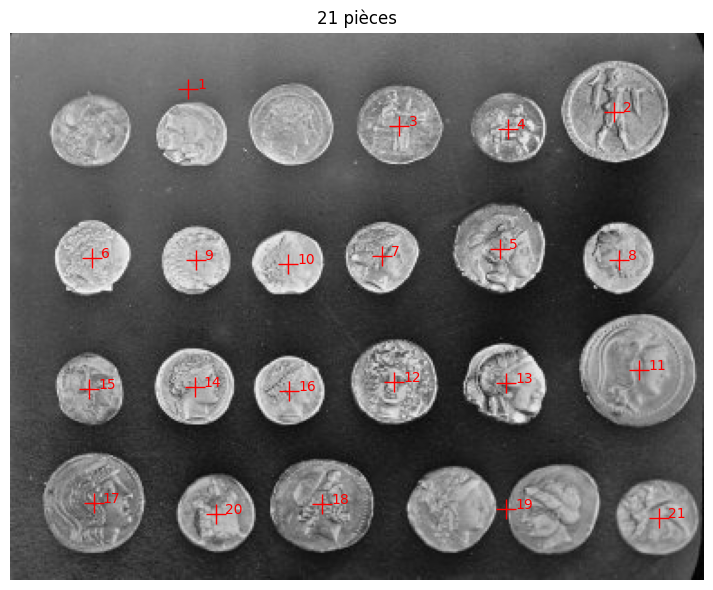

In [4]:
labels = measure.label(mask_close)
props = measure.regionprops(labels)
kept = [p for p in props if p.area >= 100]
print(f"{len(kept)} pièces détectées")

areas = np.array([p.area for p in kept])
print(f"aire : moyenne={areas.mean():.0f}, médiane={np.median(areas):.0f}, std={areas.std():.0f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(coins, cmap="gray")
for i, p in enumerate(kept, start=1):
    y, x = p.centroid
    ax.plot(x, y, "r+", markersize=14)
    ax.text(x + 5, y, str(i), color="red", fontsize=10)
ax.set_title(f"{len(kept)} pièces")
ax.axis("off")
plt.tight_layout()